In [1]:
import os
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import cv2
from PIL import Image

from collections import defaultdict

In [2]:
DATASETS = 'C:\AliCode\Datasets'
ONLINE_DATASET = 'data_online_line_width_alpha'
ONLINE_DATASET_PATH = os.path.join(DATASETS, ONLINE_DATASET)

In [3]:
df_main = None

files = [1000, 1500, 2000, 2500, 3000, 3500, 5000, 6000]
# files = [1000]
for csv in os.listdir(ONLINE_DATASET_PATH):
    if csv.startswith('main') and int(csv.split('_')[1].split('.')[0]) in files:
        tmp = pd.read_csv(os.path.join(ONLINE_DATASET_PATH, csv))
        if df_main is None:
            df_main = tmp
        else:
            df_main = pd.concat([df_main, tmp])
            

In [4]:
def normalise_time(df):
    df = df.sort_values(by='Time').copy()
    df['Time'] = df['Time'] - df['Time'].min()
    return df


def generate_temporal_features(df):
    """Given a DataFrame with columns ['Time', 'X cood.', 'Y cood.'], generate temporal features.
    Returns a DataFrame with additional columns for velocity, acceleration, curvature, and stroke segmentation.
    Features generated:
    - dx, dy: First-order differences in X and Y coordinates
    - dt: Time difference between consecutive points
    - vx, vy: Velocity components in X and Y directions
    - speed: Magnitude of velocity
    - theta: Direction of movement (angle)
    - sin_theta, cos_theta: Stable encoding of direction
    - dvx, dvy: Acceleration components in X and Y directions
    - acceleration: Magnitude of acceleration
    - curvature: Change in direction over arc length
    - pen_down: Binary indicator of pen state (if pressure data is available)
    - stroke_id: Identifier for each stroke segment
    - time_norm: Normalized global time (0 to 1)
    - stroke_time: Relative time within each stroke
    - stroke_time_norm: Normalized relative time within each stroke (0 to 1)
    """
    
    df = normalise_time(df).copy()

    # -----------------------------------
    # Basic differences
    # -----------------------------------
    df['dx'] = df['X cood.'].diff().fillna(0)
    df['dy'] = df['Y cood.'].diff().fillna(0)
    df['dt'] = df['Time'].diff().replace(0, np.nan).fillna(1)

    # -----------------------------------
    # Velocity
    # -----------------------------------
    df['vx'] = df['dx'] / df['dt']
    df['vy'] = df['dy'] / df['dt']
    df['speed'] = np.sqrt(df['vx']**2 + df['vy']**2)

    # -----------------------------------
    # Direction (stable encoding)
    # -----------------------------------
    df['theta'] = np.arctan2(df['dy'], df['dx'])
    df['sin_theta'] = np.sin(df['theta'])
    df['cos_theta'] = np.cos(df['theta'])

    # -----------------------------------
    # Acceleration
    # -----------------------------------
    df['dvx'] = df['vx'].diff().fillna(0)
    df['dvy'] = df['vy'].diff().fillna(0)
    df['acceleration'] = np.sqrt(df['dvx']**2 + df['dvy']**2)

    # -----------------------------------
    # Curvature (change in direction over arc length)
    # -----------------------------------
    df['dtheta'] = df['theta'].diff().fillna(0)
    ds = np.sqrt(df['dx']**2 + df['dy']**2)
    ds = ds.replace(0, np.nan).fillna(1e-6)
    df['curvature'] = df['dtheta'] / ds

    # -----------------------------------
    # Pen state (if pressure available)
    # -----------------------------------
    if 'Pressure' in df.columns:
        df['pen_down'] = (df['Pressure'] > 0).astype(int)
    else:
        df['pen_down'] = 1

    # -----------------------------------
    # Stroke segmentation
    # -----------------------------------
    df['stroke_id'] = (df['pen_down'].diff() == 1).cumsum()

    # -----------------------------------
    # Normalized global time
    # -----------------------------------
    df['time_norm'] = df['Time'] / df['Time'].max()

    # -----------------------------------
    # Relative time within stroke
    # -----------------------------------
    df['stroke_time'] = df.groupby('stroke_id')['Time'].transform(
        lambda x: x - x.min()
    )
    df['stroke_duration'] = df.groupby('stroke_id')['stroke_time'].transform(
        'max'
    ).replace(0, 1e-6)

    df['stroke_time_norm'] = df['stroke_time'] / df['stroke_duration']

    return df

In [5]:
def tight_crop_img(img_path, thresh_val=250):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, thresh_val, 255, cv2.THRESH_BINARY_INV
    )

    ys, xs = np.where(thresh > 0)
    if len(xs) == 0 or len(ys) == 0:
        return img

    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    return img[y1:y2, x1:x2]

# def scale(df, scaler, gamma=2.0, min_width=1.5, max_width=7):
#     # csv = df[df['Pressure'] > 0]
#     csv = df.copy()
#     csv_scaled = scaler.transform(csv)
#     csv_scaled = pd.DataFrame(csv_scaled, columns=csv.columns)
#     linewidths = min_width + (csv_scaled ** gamma) * (max_width - min_width)
    
#     return linewidths

def scale_pressure(values, stats, gamma=1.0):
    mask = values > 0
    
    low = stats["Pressure"]["low"]
    high = stats["Pressure"]["high"]
    
    clipped = np.clip(values, low, high)
    
    scaled = np.zeros_like(values, dtype=float)
    scaled[mask] = (clipped[mask] - low) / (high - low)
    
    # gamma amplification
    scaled[mask] = scaled[mask] ** gamma
    
    return scaled

def col_to_linewidth(scaled, min_width=1.5, max_width=7):
    return min_width + scaled * (max_width - min_width)

def scale_tilt(values, stats, feature_name, pressure_mask, alpha=1):
    """
    values: numpy array (full sequence)
    stats: global stats dictionary
    feature_name: "X tilt" or "Y tilt"
    """
    # mask = values != 0  # or use pressure mask if preferred
    mask = pressure_mask
    
    mean = stats[feature_name]["mean"]
    std = stats[feature_name]["std"]
    
    z = np.zeros_like(values, dtype=float)
    z[mask] = (values[mask] - mean) / std
    
    # compress
    scaled = np.zeros_like(values, dtype=float)
    scaled[mask] = np.tanh(alpha * z[mask])
    
    # map from [-1,1] to [0,1]
    scaled[mask] = (scaled[mask] + 1) / 2
    
    return scaled

def scale(col, **kwargs):
    if col == "Pressure":
        return scale_pressure(values=kwargs["values"], stats=kwargs["stats"], gamma=kwargs.get("gamma", 1.0))
    # elif col in ["X tilt", "Y tilt"]:
    else:
        return scale_tilt(values=kwargs["values"], stats=kwargs["stats"], feature_name=col, pressure_mask=kwargs["pressure_mask"], alpha=kwargs.get("alpha", 1))
    # else:
        # raise ValueError(f"Unsupported column: {col}")
        # return kwargs["values"]

def draw_strokes(df, linewidths):
    plt.clf()
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    
    pressure = df['Pressure'].values
    x = df['X cood.'].values
    y = df['Y cood.'].values
    
    for i in range(len(x)-1):
        if pressure[i] > 0 and pressure[i+1] > 0:
            plt.plot(
                x[i:i+2],
                y[i:i+2],
                linewidth=linewidths[i],
                color='black'
            )
    
    plt.axis('off')

In [7]:
os.chdir(ONLINE_DATASET_PATH)
i = 0
for record in tqdm(df_main.itertuples(), total=len(df_main)):
    if i >= 1:
        break
    csv = pd.read_csv(record.csv)
    csv = generate_temporal_features(csv)
    # folder = os.path.dirname(record.csv).replace('csv', 'temporal', 1)
    # os.makedirs(folder, exist_ok=True)
    # name = os.path.basename(record.csv).split('.')[0].replace('csv', 'temporal', 1) + "_temporal.csv"
    csv.to_csv(record.csv, index=False)

100%|██████████| 2403/2403 [06:39<00:00,  6.01it/s]


In [8]:
feature_values = defaultdict(list)

os.chdir(ONLINE_DATASET_PATH)
df = pd.read_csv('train_leakproof.csv')

for record in tqdm(df.itertuples()):
    csv = pd.read_csv(record.csv)
    
    # Only pen-down
    csv = csv[csv["Pressure"] > 0]
    
    for col in ["dx", "dy", "vx", "vy", "speed", "sin_theta", "cos_theta", "dvx", "dvy", "acceleration", "curvature"]:
        feature_values[col].append(csv[col].values)

# Concatenate
stats = {}

for col in feature_values:
    values = np.concatenate(feature_values[col])
    low = np.percentile(values, 5)
    high = np.percentile(values, 95)
    mean = values.mean()
    std = values.std()
    
    stats[col] = {
        "low": low,
        "high": high,
        "mean": mean,
        "std": std
    }

9it [00:00, 23.04it/s]

1911it [01:14, 25.69it/s]


In [9]:
def rasterize_feature(df, feature_values):

    x = df['X cood.'].values
    y = df['Y cood.'].values
    f = feature_values.copy()

    # Shift to origin (important)
    x = x - x.min()
    y = y - y.min()

    H = int(y.max()) + 1
    W = int(x.max()) + 1

    canvas = np.ones((H, W), dtype=np.float32)

    xi = x.astype(int)
    yi = y.astype(int)

    # Normalize feature
    # f_min, f_max = f.min(), f.max()
    # if f_max - f_min > 0:
    #     f = 1 - (f - f_min) / (f_max - f_min)

    for i in range(len(xi)):
        canvas[yi[i], xi[i]] = min(canvas[yi[i], xi[i]], f[i])

    return canvas

  0%|          | 0/2403 [00:00<?, ?it/s]

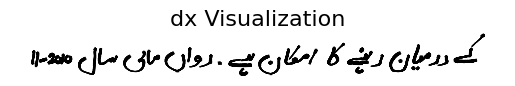

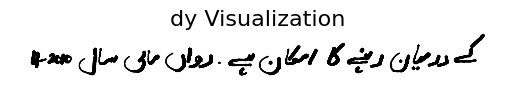

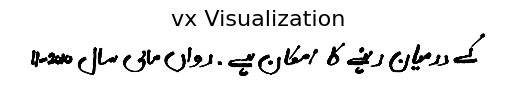

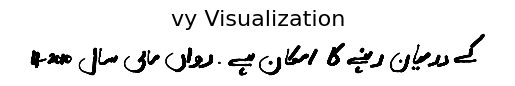

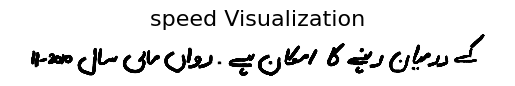

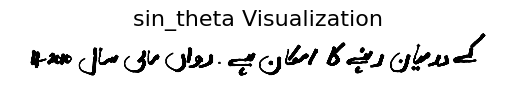

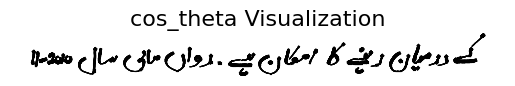

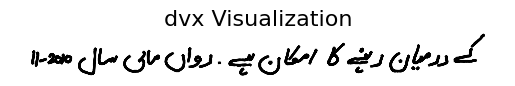

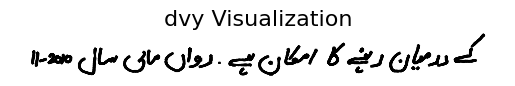

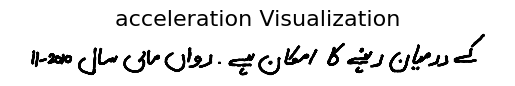

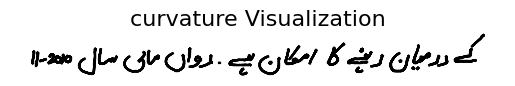

  0%|          | 1/2403 [00:33<22:09:13, 33.20s/it]


In [11]:
# Key based Image Generation
os.chdir(ONLINE_DATASET_PATH)
i = 0
for record in tqdm(df_main.itertuples(), total=len(df_main)):
    if i >= 1:
        break
    csv = pd.read_csv(record.csv)
    # csv = generate_temporal_features(csv)
    
    # for col in ['Pressure', 'X tilt', 'Y tilt', 'Height', 'Thickness']:
    # for col in ['Pressure', 'X tilt', 'Y tilt', "Stroke"]:
    # for col in ['Pressure', 'X tilt', 'Y tilt', "Stroke"]:
    # for col in ["Stroke", "dx", "dy", "vx", "vy", "speed", "sin_theta", "cos_theta", "dvx", "dvy", "acceleration", "curvature"]:
    for col in ["dx", "dy", "vx", "vy", "speed", "sin_theta", "cos_theta", "dvx", "dvy", "acceleration", "curvature"]:
        if col == "Stroke":
            scaled = np.zeros_like(csv["Pressure"].values) 
        else:
            scaled = scale(col, values=csv[col].values, stats=stats, feature_name=col, gamma=1.3, pressure_mask=csv["Pressure"].values > 0, alpha=1.3)
            # scaled = csv[col].values
        
        
        # print(scaled.min(), scaled.max())
        draw_strokes(csv, col_to_linewidth(scaled, min_width=0.75, max_width=2.25))
        # canvas = rasterize_feature(csv, feature_values=col_to_linewidth(scaled, min_width=0, max_width=1))
        # plt.imshow(canvas, cmap='gray')
        # plt.title(f'{col} Visualization', fontsize=16)
        
        name = record.csv.split('/')
        name[2] = f'img_{col}'
        os.makedirs('/'.join(name[:-1]), exist_ok=True)
        name = '/'.join(name)[:-4] + '.png'
        name = name.replace('csv', 'img')
        # plt.savefig(name, dpi=300, bbox_inches='tight', pad_inches=0)
        
        # cropped = tight_crop_img(name, thresh_val=254)
        # cv2.imwrite(name, cropped)
        plt.title(f'{col} Visualization', fontsize=16)
        plt.show()
        # plt.clf()
        # plt.imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        # plt.axis('off')
        # plt.show()
        
        # plt.clf()
        # plt.hist(scaled[csv["Pressure"].values > 0], bins=50)
        # plt.title(f'{col} Scaled Distribution', fontsize=16)
        # plt.show()
    i+=1